<a href="https://colab.research.google.com/github/mhabibier/Practical-Statistics-for-Data-Scientists/blob/main/02_Data_and_Sampling_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Data and Sampling Distributions

**Buku:** Practical Statistics for Data Scientists, Second Edition  
**Penulis:** Peter Bruce, Andrew Bruce, and Peter Gedeck  
**Nama:** Muhammad Habibie Rabbani  
**NIM:** 101032300005  
**Program studi:** Computer Engineering  
**University:** Telkom University  

Notebook ini berisi reproduksi kode, penjelasan teori, visualisasi,
dan analisis Chapter 2 mengenai data dan sampling distributions.

## 1. Data and Sampling Distributions

Pada praktiknya, data scientist sering tidak menganalisis seluruh
population. Analisis biasanya dilakukan pada sample yang diambil dari
population tersebut.

Istilah penting:

- **Population**: seluruh objek atau data yang menjadi sasaran analisis.
- **Sample**: sebagian anggota population yang dianalisis.
- **Parameter**: nilai numerik yang menggambarkan population.
- **Statistic**: nilai numerik yang dihitung dari sample.
- **Sampling**: proses memilih sample dari population.
- **Sampling distribution**: distribusi suatu statistic yang diperoleh
  dari banyak sample.

Sample harus mewakili population. Sample yang besar belum tentu baik
jika proses pemilihannya menghasilkan bias.

In [1]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option(
    "display.float_format",
    "{:,.4f}".format
)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


In [2]:
REPOSITORY_URL = (
    "https://github.com/gedeck/"
    "practical-statistics-for-data-scientists.git"
)

REPOSITORY_DIRECTORY = Path(
    "/content/practical-statistics-for-data-scientists"
)

DATA_DIRECTORY = (
    REPOSITORY_DIRECTORY
    / "data"
)

if not REPOSITORY_DIRECTORY.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPOSITORY_URL,
            str(REPOSITORY_DIRECTORY)
        ],
        check=True
    )

if not DATA_DIRECTORY.exists():
    raise FileNotFoundError(
        "Folder dataset tidak ditemukan."
    )

print("Dataset tersedia di:", DATA_DIRECTORY)

Dataset tersedia di: /content/practical-statistics-for-data-scientists/data


In [3]:
loans_income = pd.read_csv(
    DATA_DIRECTORY / "loans_income.csv"
).squeeze("columns")

loans_income.name = "Income"

sp500_data = pd.read_csv(
    DATA_DIRECTORY / "sp500_data.csv.gz",
    index_col=0
)

sp500_data.index = pd.to_datetime(
    sp500_data.index
)

print(
    "Ukuran Loans Income:",
    loans_income.shape
)

print(
    "Ukuran S&P 500:",
    sp500_data.shape
)

display(
    loans_income
    .describe()
    .to_frame()
)

Ukuran Loans Income: (50000,)
Ukuran S&P 500: (5647, 517)


,Income
count,"50,000.0000"
mean,"68,760.5184"
std,"32,872.0354"
min,"4,000.0000"
25%,"45,000.0000"
50%,"62,000.0000"
75%,"85,000.0000"
max,"199,000.0000"


### Analisis Awal Dataset

Dataset `loans_income` berisi 50.000 nilai pendapatan peminjam.
Rata-rata pendapatan sekitar 68.761, sedangkan median sebesar 62.000.

Mean yang lebih tinggi daripada median menunjukkan bahwa distribusi
pendapatan cenderung memiliki ekor ke kanan. Beberapa pendapatan tinggi
meningkatkan nilai rata-rata.

Dataset `sp500_data` berisi perubahan nilai saham yang akan digunakan
untuk mempelajari long-tailed distribution.

## 2. Population and Sample

Population adalah seluruh data yang menjadi sasaran analisis. Sample
adalah sebagian data yang dipilih untuk mewakili population.

Sebagai contoh:

- Seluruh mahasiswa Telkom University merupakan population.
- Seribu mahasiswa yang dipilih untuk survei merupakan sample.
- Rata-rata tinggi seluruh mahasiswa merupakan population parameter.
- Rata-rata tinggi seribu mahasiswa tersebut merupakan sample statistic.

Sample statistic digunakan untuk memperkirakan population parameter
yang biasanya tidak diketahui.

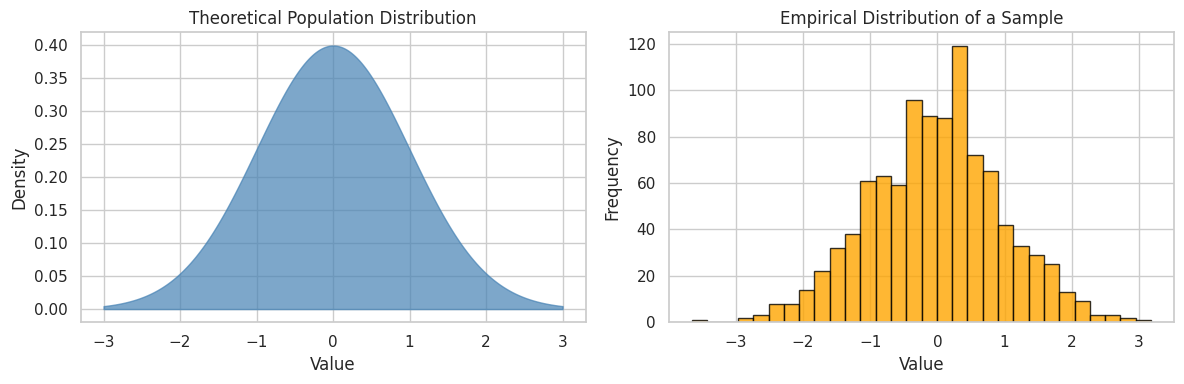

In [4]:
random_generator = np.random.default_rng(
    42
)

x_values = np.linspace(
    -3,
    3,
    300
)

normal_sample = random_generator.normal(
    loc=0,
    scale=1,
    size=1000
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].fill_between(
    x_values,
    stats.norm.pdf(
        x_values,
        loc=0,
        scale=1
    ),
    color="steelblue",
    alpha=0.7
)

axes[0].set_title(
    "Theoretical Population Distribution"
)

axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

axes[1].hist(
    normal_sample,
    bins=30,
    color="orange",
    edgecolor="black",
    alpha=0.8
)

axes[1].set_title(
    "Empirical Distribution of a Sample"
)

axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Analisis Population dan Sample

Grafik kiri merupakan distribusi population secara teoretis, sedangkan
grafik kanan merupakan distribusi empiris dari 1.000 data sample.

Bentuk sample mendekati bentuk population, tetapi tidak sama persis.
Perbedaan tersebut muncul karena random sampling variation.

Jika sample lain diambil, histogram yang dihasilkan akan sedikit
berbeda walaupun berasal dari population yang sama.

## 3. Random Sampling and Sample Bias

### Random Sampling

Random sampling adalah proses memilih data sehingga setiap anggota
population memiliki kesempatan yang diketahui untuk terpilih.

Random sampling membantu menghasilkan sample yang mewakili population.

### Sampling with Replacement

Setelah satu data dipilih, data tersebut dikembalikan ke population.
Data yang sama dapat dipilih lebih dari satu kali.

### Sampling without Replacement

Setelah satu data dipilih, data tersebut tidak dikembalikan. Satu data
hanya dapat dipilih satu kali dalam sample.

### Bias

Bias adalah kesalahan sistematis yang menyebabkan hasil analisis
cenderung menyimpang ke arah tertentu.

### Sample Bias

Sample bias terjadi ketika karakteristik sample secara sistematis
berbeda dari population yang ingin diwakili.

Contoh sample bias adalah survei penggunaan internet yang hanya
dilakukan melalui media sosial. Orang yang tidak menggunakan media
sosial hampir tidak mempunyai kesempatan untuk terpilih.

### Size versus Quality

Sample besar mengurangi random sampling error, tetapi tidak secara
otomatis menghilangkan bias. Sample kecil yang dipilih dengan benar
dapat lebih berguna daripada sample sangat besar yang proses
pemilihannya bias.

In [5]:
sample_without_replacement = (
    loans_income.sample(
        n=1000,
        replace=False,
        random_state=42
    )
)

sample_with_replacement = (
    loans_income.sample(
        n=1000,
        replace=True,
        random_state=42
    )
)

population_and_samples = pd.DataFrame({
    "Dataset": [
        "Population",
        "Sample without replacement",
        "Sample with replacement"
    ],
    "Number of Data": [
        len(loans_income),
        len(sample_without_replacement),
        len(sample_with_replacement)
    ],
    "Mean": [
        loans_income.mean(),
        sample_without_replacement.mean(),
        sample_with_replacement.mean()
    ],
    "Median": [
        loans_income.median(),
        sample_without_replacement.median(),
        sample_with_replacement.median()
    ]
})

population_and_samples

,Dataset,Number of Data,Mean,Median
0,Population,50000,"68,760.5184","62,000.0000"
1,Sample without replacement,1000,"66,536.4730","60,000.0000"
2,Sample with replacement,1000,"68,039.6660","60,000.0000"


### Analisis Random Sampling

Mean setiap sample tidak sama persis dengan population mean. Perbedaan
ini disebut sampling variation dan terjadi secara alami karena hanya
sebagian population yang digunakan.

Sample without replacement menghasilkan mean sekitar 66.536, sedangkan
population mean sekitar 68.761. Jika random sample baru dibuat, hasilnya
dapat berubah.

Sampling with replacement memungkinkan data pendapatan yang sama
terpilih lebih dari satu kali. Mekanisme ini nantinya digunakan dalam
bootstrap.

## 4. Sample Mean versus Population Mean

Population mean dilambangkan dengan:

$$
\mu = \frac{\sum_{i=1}^{N}x_i}{N}
$$

Sample mean dilambangkan dengan:

$$
\bar{x} = \frac{\sum_{i=1}^{n}x_i}{n}
$$

Population mean merupakan nilai sebenarnya dari seluruh population.
Sample mean merupakan perkiraan terhadap population mean.

Jika random sample diambil berulang kali, setiap sample dapat
menghasilkan mean yang berbeda. Namun, rata-rata dari seluruh sample
means akan cenderung mendekati population mean.

## 5. Selection Bias

Selection bias terjadi ketika data dipilih dengan cara yang tidak acak
dan pemilihannya berhubungan dengan hasil yang dianalisis.

Contoh selection bias:

1. Memilih data yang hanya mendukung kesimpulan tertentu.
2. Menghentikan eksperimen ketika hasil terlihat menguntungkan.
3. Membandingkan banyak variabel, tetapi hanya melaporkan hasil yang
   paling menarik.
4. Melakukan survei hanya kepada kelompok yang mudah dijangkau.

Selection bias berbeda dari random sampling error. Random sampling
error terjadi secara acak, sedangkan selection bias bersifat sistematis.

## 6. Regression to the Mean

Regression to the mean adalah kecenderungan hasil yang sangat ekstrem
untuk menjadi lebih dekat dengan rata-rata ketika pengukuran diulang.

Hasil ekstrem biasanya merupakan gabungan kondisi sebenarnya dan unsur
acak. Ketika pengukuran diulang, unsur acak tersebut kemungkinan tidak
muncul dengan tingkat ekstrem yang sama.

Regression to the mean tidak berarti seluruh nilai pasti menjadi sama
dengan mean. Konsep ini menjelaskan kecenderungan rata-rata suatu
kelompok ekstrem pada pengukuran berikutnya.

In [6]:
random_generator = np.random.default_rng(
    42
)

number_of_students = 2000

true_ability = random_generator.normal(
    loc=70,
    scale=7,
    size=number_of_students
)

first_test = (
    true_ability
    + random_generator.normal(
        loc=0,
        scale=8,
        size=number_of_students
    )
)

second_test = (
    true_ability
    + random_generator.normal(
        loc=0,
        scale=8,
        size=number_of_students
    )
)

test_results = pd.DataFrame({
    "True Ability": true_ability,
    "First Test": first_test,
    "Second Test": second_test
})

top_students = test_results.nlargest(
    200,
    "First Test"
)

regression_summary = (
    top_students[
        [
            "True Ability",
            "First Test",
            "Second Test"
        ]
    ]
    .mean()
    .to_frame("Mean Score")
)

regression_summary

,Mean Score
True Ability,78.0970
First Test,88.6782
Second Test,79.3046


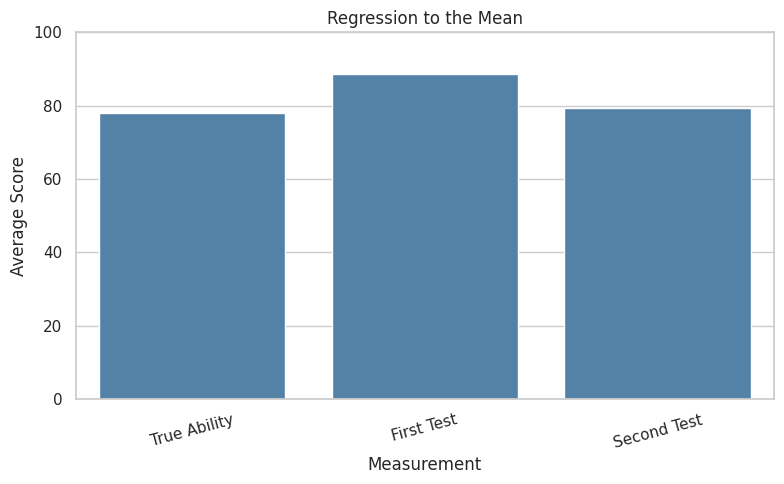

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=regression_summary.index,
    y=regression_summary["Mean Score"],
    color="steelblue"
)

plt.ylim(0, 100)
plt.xlabel("Measurement")
plt.ylabel("Average Score")
plt.title("Regression to the Mean")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Analisis Regression to the Mean

Mahasiswa dipilih karena memperoleh hasil sangat tinggi pada tes
pertama. Rata-rata tes pertama kelompok tersebut sekitar 88,68.

Pada tes kedua, rata-ratanya menurun menjadi sekitar 79,30 dan lebih
dekat dengan kemampuan sebenarnya, yaitu sekitar 78,10.

Penurunan tersebut tidak selalu berarti kemampuan mereka memburuk.
Nilai tes pertama menjadi sangat tinggi karena dipengaruhi kemampuan
dan random variation yang positif.

## 7. Sampling Distribution of a Statistic

Sampling distribution adalah distribusi suatu statistic yang diperoleh
dari banyak random sample dengan ukuran yang sama.

Contohnya, untuk membentuk sampling distribution of the mean:

1. Ambil random sample dari population.
2. Hitung mean sample tersebut.
3. Ulangi proses berkali-kali.
4. Kumpulkan seluruh sample mean.
5. Visualisasikan distribusi sample mean.

Sampling distribution berbeda dari distribution of the data.

- Distribution of the data berisi nilai setiap individu.
- Sampling distribution berisi nilai statistic dari banyak sample.

In [8]:
income_values = loans_income.to_numpy()

sampling_generator = np.random.default_rng(
    42
)

individual_income = sampling_generator.choice(
    income_values,
    size=1000,
    replace=False
)

sample_sizes = [
    5,
    20,
    100
]

sample_mean_distributions = {}

for sample_size in sample_sizes:
    sample_means = []

    for repetition in range(1000):
        current_sample = (
            sampling_generator.choice(
                income_values,
                size=sample_size,
                replace=False
            )
        )

        sample_means.append(
            current_sample.mean()
        )

    sample_mean_distributions[
        sample_size
    ] = np.array(sample_means)

distribution_frames = [
    pd.DataFrame({
        "Income": individual_income,
        "Distribution": "Individual data"
    })
]

for sample_size in sample_sizes:
    distribution_frames.append(
        pd.DataFrame({
            "Income":
                sample_mean_distributions[
                    sample_size
                ],
            "Distribution":
                f"Mean of {sample_size}"
        })
    )

sampling_distribution_data = pd.concat(
    distribution_frames,
    ignore_index=True
)

sampling_distribution_data.head()

,Income,Distribution
0,"60,000.0000",Individual data
1,"60,000.0000",Individual data
2,"43,000.0000",Individual data
3,"50,000.0000",Individual data
4,"40,400.0000",Individual data


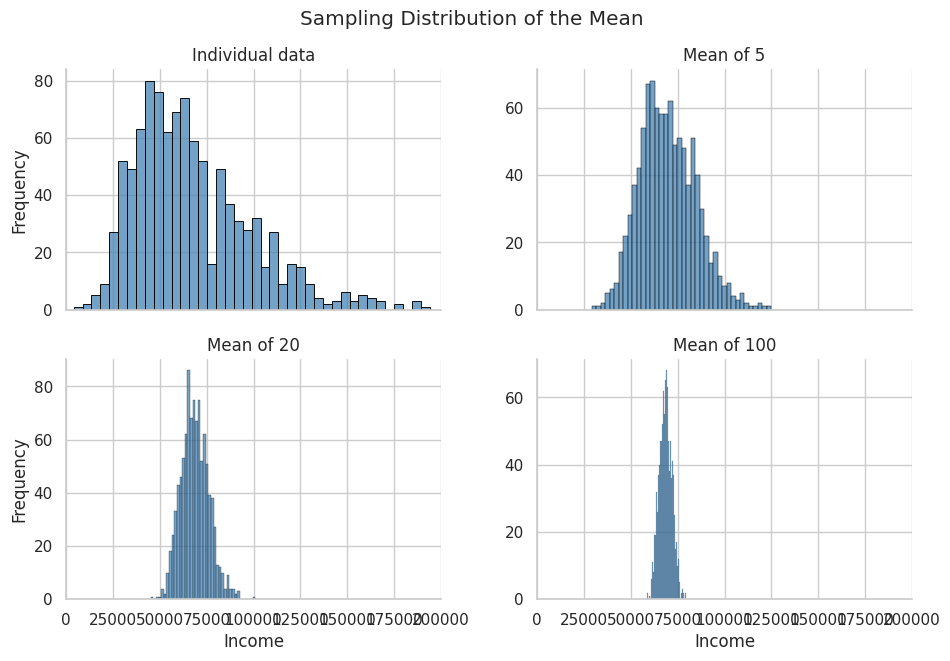

In [9]:
facet = sns.FacetGrid(
    sampling_distribution_data,
    col="Distribution",
    col_wrap=2,
    height=3.2,
    aspect=1.5,
    sharex=True,
    sharey=False
)

facet.map_dataframe(
    sns.histplot,
    x="Income",
    bins=40,
    color="steelblue",
    edgecolor="black"
)

facet.set(
    xlim=(0, 200_000)
)

facet.set_axis_labels(
    "Income",
    "Frequency"
)

facet.set_titles(
    "{col_name}"
)

facet.figure.suptitle(
    "Sampling Distribution of the Mean",
    y=1.03
)

plt.show()

### Analisis Sampling Distribution

Distribusi data individual terlihat menyebar dan memiliki ekor ke
kanan. Ketika mean dihitung dari sample berukuran 5, distribusi sample
mean masih cukup lebar.

Distribusi mean dari sample berukuran 20 lebih sempit dan lebih simetris.
Distribusi mean dari sample berukuran 100 menjadi semakin sempit dan
terpusat di sekitar population mean.

Semakin besar ukuran sample, semakin kecil variasi sample mean.

## 8. Central Limit Theorem

Central Limit Theorem atau CLT menyatakan bahwa sampling distribution
of the mean akan mendekati distribusi normal ketika ukuran sample
bertambah besar, walaupun data asalnya tidak berdistribusi normal.

CLT tidak berarti bahwa data individual menjadi normal. Yang mendekati
normal adalah distribusi dari sample means.

CLT bekerja dengan baik ketika:

- Sample dipilih secara independen.
- Sample berasal dari population yang sama.
- Ukuran sample cukup besar.
- Population tidak memiliki kondisi ekstrem yang sangat berat.

## 9. Standard Error

Standard error mengukur variasi suatu sample statistic dari satu sample
ke sample lainnya.

Untuk sample mean:

$$
SE = \frac{s}{\sqrt{n}}
$$

Keterangan:

- $SE$ adalah standard error.
- $s$ adalah sample standard deviation.
- $n$ adalah ukuran sample.

Ketika ukuran sample menjadi empat kali lebih besar, standard error
hanya menjadi sekitar setengahnya.

In [10]:
population_standard_deviation = (
    loans_income.std()
)

standard_error_comparison = []

for sample_size in sample_sizes:
    empirical_standard_error = (
        sample_mean_distributions[
            sample_size
        ].std(ddof=1)
    )

    theoretical_standard_error = (
        population_standard_deviation
        / np.sqrt(sample_size)
    )

    standard_error_comparison.append({
        "Sample Size": sample_size,
        "Empirical Standard Error":
            empirical_standard_error,
        "Theoretical Standard Error":
            theoretical_standard_error
    })

standard_error_table = pd.DataFrame(
    standard_error_comparison
)

standard_error_table

,Sample Size,Empirical Standard Error,Theoretical Standard Error
0,5,"14,999.0334","14,700.8211"
1,20,"7,484.0086","7,350.4106"
2,100,"3,402.4601","3,287.2035"


### Analisis Standard Error

Standard error menurun ketika ukuran sample meningkat. Sample berukuran
5 menghasilkan standard error sekitar 15.000, sedangkan sample
berukuran 100 menghasilkan standard error sekitar 3.400.

Empirical standard error mendekati hasil rumus teoritis. Perbedaan kecil
terjadi karena jumlah pengulangan simulasi terbatas.

Hasil tersebut menunjukkan bahwa sample yang lebih besar menghasilkan
perkiraan mean yang lebih stabil.

## 10. The Bootstrap

Bootstrap adalah metode untuk memperkirakan sampling distribution
dengan mengambil sample berulang kali dari data yang tersedia.

Setiap bootstrap sample:

- Memiliki ukuran yang sama dengan original sample.
- Dibentuk dengan replacement.
- Dapat berisi data yang sama lebih dari satu kali.

Tahapan bootstrap:

1. Ambil sample dengan replacement dari original sample.
2. Hitung statistic yang diinginkan.
3. Ulangi proses banyak kali.
4. Gunakan distribusi hasil statistic untuk menghitung bias,
   standard error, atau confidence interval.

### Resampling versus Bootstrapping

Resampling merupakan istilah umum untuk menggunakan data secara
berulang. Bootstrap merupakan salah satu jenis resampling yang secara
khusus mengambil sample dengan replacement.

Bootstrap tidak menciptakan informasi baru. Kualitas hasil bootstrap
tetap bergantung pada kemampuan original sample dalam mewakili
population.

In [11]:
bootstrap_generator = (
    np.random.default_rng(42)
)

number_of_bootstraps = 1000

bootstrap_medians = []

for repetition in range(
    number_of_bootstraps
):
    bootstrap_sample = (
        bootstrap_generator.choice(
            income_values,
            size=len(income_values),
            replace=True
        )
    )

    bootstrap_medians.append(
        np.median(bootstrap_sample)
    )

bootstrap_medians = np.array(
    bootstrap_medians
)

original_median = np.median(
    income_values
)

bootstrap_bias = (
    bootstrap_medians.mean()
    - original_median
)

bootstrap_standard_error = (
    bootstrap_medians.std(ddof=1)
)

print(
    "Original median:",
    f"{original_median:,.2f}"
)

print(
    "Bootstrap bias:",
    f"{bootstrap_bias:,.2f}"
)

print(
    "Bootstrap standard error:",
    f"{bootstrap_standard_error:,.2f}"
)

Original median: 62,000.00
Bootstrap bias: -63.93
Bootstrap standard error: 191.47


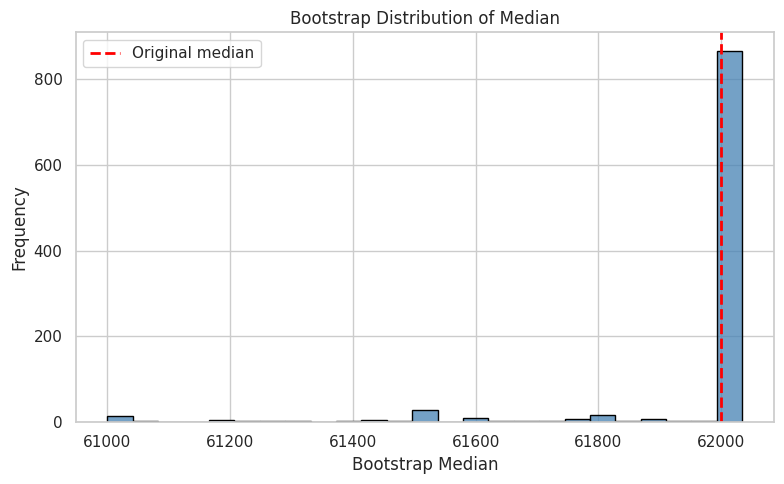

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    bootstrap_medians,
    bins=25,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    original_median,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Original median"
)

plt.xlabel("Bootstrap Median")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Median")
plt.legend()
plt.tight_layout()
plt.show()

### Analisis Bootstrap

Original median adalah 62.000. Bootstrap bias relatif kecil
dibandingkan nilai median, sehingga bootstrap estimate tidak jauh dari
statistic asli.

Bootstrap standard error sekitar 191 menunjukkan tingkat variasi
median dari satu bootstrap sample ke bootstrap sample lainnya.

Distribusi bootstrap dapat digunakan untuk mengukur ketidakpastian
statistic tanpa harus mengetahui bentuk distribusi population secara
teoretis.

## 11. Confidence Intervals

Confidence interval memberikan rentang nilai yang masuk akal untuk
population parameter berdasarkan sample.

Bentuk umum confidence interval adalah:

$$
Estimate \pm Margin\ of\ Error
$$

Pada pendekatan bootstrap, batas confidence interval diperoleh dari
persentil bootstrap distribution.

Sebagai contoh:

- 90% confidence interval menggunakan persentil 5% dan 95%.
- 95% confidence interval menggunakan persentil 2,5% dan 97,5%.

Confidence level yang lebih tinggi menghasilkan interval yang lebih
lebar.

Interpretasi frequentist yang tepat adalah: jika prosedur sampling dan
pembuatan interval diulang berkali-kali, sekitar 95% interval yang
dibentuk dengan metode 95% akan mencakup population parameter.

In [13]:
sample_of_twenty = (
    loans_income.sample(
        n=20,
        replace=False,
        random_state=3
    )
)

confidence_generator = (
    np.random.default_rng(42)
)

bootstrap_means = []

for repetition in range(5000):
    bootstrap_sample = (
        confidence_generator.choice(
            sample_of_twenty.to_numpy(),
            size=len(sample_of_twenty),
            replace=True
        )
    )

    bootstrap_means.append(
        bootstrap_sample.mean()
    )

bootstrap_means = np.array(
    bootstrap_means
)

confidence_interval_90 = np.quantile(
    bootstrap_means,
    [0.05, 0.95]
)

confidence_interval_95 = np.quantile(
    bootstrap_means,
    [0.025, 0.975]
)

print(
    "Population mean:",
    f"{loans_income.mean():,.2f}"
)

print(
    "Sample mean:",
    f"{sample_of_twenty.mean():,.2f}"
)

print(
    "Bootstrap mean:",
    f"{bootstrap_means.mean():,.2f}"
)

print(
    "90% confidence interval:",
    np.round(
        confidence_interval_90,
        2
    )
)

print(
    "95% confidence interval:",
    np.round(
        confidence_interval_95,
        2
    )
)

Population mean: 68,760.52
Sample mean: 55,734.10
Bootstrap mean: 55,839.07
90% confidence interval: [43310.7  69687.71]
95% confidence interval: [41179.78 73000.85]


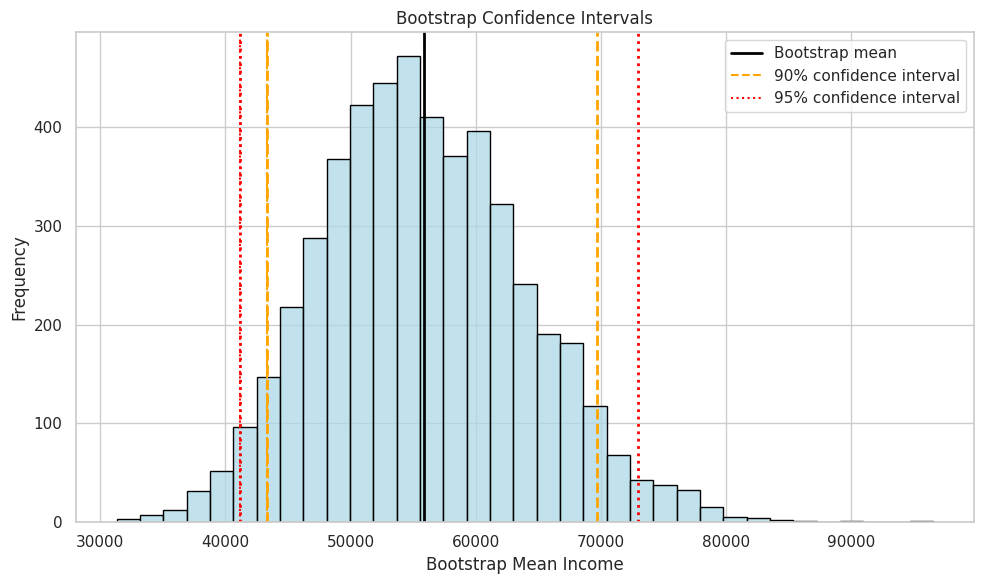

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    bootstrap_means,
    bins=35,
    color="lightblue",
    edgecolor="black"
)

for boundary in confidence_interval_90:
    plt.axvline(
        boundary,
        color="orange",
        linestyle="--",
        linewidth=2
    )

for boundary in confidence_interval_95:
    plt.axvline(
        boundary,
        color="red",
        linestyle=":",
        linewidth=2
    )

plt.axvline(
    bootstrap_means.mean(),
    color="black",
    linewidth=2,
    label="Bootstrap mean"
)

plt.axvline(
    confidence_interval_90[0],
    color="orange",
    linestyle="--",
    label="90% confidence interval"
)

plt.axvline(
    confidence_interval_95[0],
    color="red",
    linestyle=":",
    label="95% confidence interval"
)

plt.xlabel("Bootstrap Mean Income")
plt.ylabel("Frequency")
plt.title("Bootstrap Confidence Intervals")
plt.legend()
plt.tight_layout()
plt.show()

### Analisis Confidence Interval

Sample berukuran 20 menghasilkan mean sekitar 55.734, sedangkan
population mean sekitar 68.761. Perbedaan ini menunjukkan bahwa sample
kecil dapat menghasilkan perkiraan yang cukup jauh dari parameter
population.

Interval 95% lebih lebar daripada interval 90% karena tingkat keyakinan
yang lebih tinggi memerlukan rentang yang lebih luas.

Population mean pada contoh ini masih berada di dalam interval 90% dan
95%, tetapi posisinya mendekati batas atas karena sample mean yang
diperoleh lebih rendah daripada population mean.

## 12. Normal Distribution

Normal distribution adalah distribusi kontinu berbentuk simetris
seperti lonceng.

Distribusi normal ditentukan oleh:

- Mean $\mu$, yang menentukan pusat distribusi.
- Standard deviation $\sigma$, yang menentukan penyebaran.

Pada distribusi normal:

- Sekitar 68% data berada dalam $\mu \pm 1\sigma$.
- Sekitar 95% data berada dalam $\mu \pm 2\sigma$.
- Sekitar 99,7% data berada dalam $\mu \pm 3\sigma$.

### Standard Normal Distribution

Standard normal distribution memiliki:

$$
\mu = 0
$$

dan:

$$
\sigma = 1
$$

Nilai data dapat diubah menjadi z-score:

$$
z = \frac{x-\mu}{\sigma}
$$

### QQ-Plot

QQ-plot membandingkan quantile data dengan quantile distribusi
teoretis. Jika titik-titik mengikuti garis diagonal, data relatif
sesuai dengan distribusi tersebut.

In [15]:
standardized_income = (
    sample_without_replacement
    - sample_without_replacement.mean()
) / sample_without_replacement.std()

print(
    "Mean setelah standardisasi:",
    round(
        standardized_income.mean(),
        6
    )
)

print(
    "Standard deviation:",
    round(
        standardized_income.std(),
        6
    )
)

Mean setelah standardisasi: 0.0
Standard deviation: 1.0


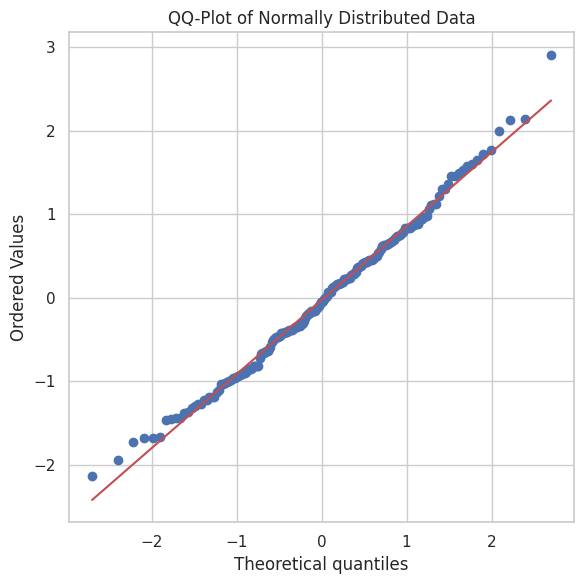

In [16]:
normal_generator = np.random.default_rng(
    42
)

normal_data = normal_generator.normal(
    loc=0,
    scale=1,
    size=200
)

figure, axis = plt.subplots(
    figsize=(6, 6)
)

stats.probplot(
    normal_data,
    dist="norm",
    plot=axis
)

axis.set_title(
    "QQ-Plot of Normally Distributed Data"
)

plt.tight_layout()
plt.show()

### Analisis Normal QQ-Plot

Sebagian besar titik berada dekat dengan garis diagonal. Hal ini
menunjukkan bahwa data hasil simulasi relatif sesuai dengan distribusi
normal.

Penyimpangan kecil pada bagian ujung masih dapat terjadi karena random
variation dan jumlah sample yang terbatas.

## 13. Long-Tailed Distributions

Long-tailed distribution mempunyai peluang nilai ekstrem yang lebih
besar daripada normal distribution.

Pada QQ-plot, long-tailed distribution biasanya menunjukkan
penyimpangan dari garis diagonal pada bagian ekor.

Long-tailed distribution penting dalam data science karena data
keuangan, pendapatan, waktu tunggu, dan kerugian sering memiliki nilai
ekstrem yang lebih banyak daripada prediksi distribusi normal.

Mengasumsikan normal distribution pada data berekor panjang dapat
menyebabkan risiko nilai ekstrem diremehkan.

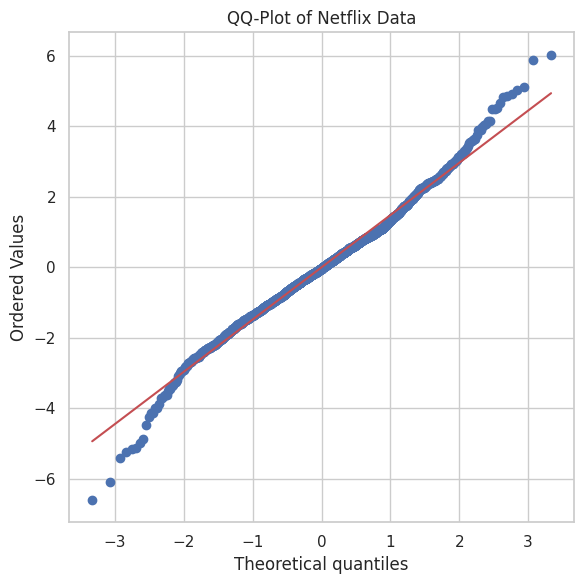

Excess kurtosis: 1.225


In [17]:
netflix_values = sp500_data[
    "NFLX"
]

positive_netflix_values = (
    netflix_values[
        netflix_values > 0
    ]
)

netflix_transformed = np.diff(
    np.log(
        positive_netflix_values
    )
)

figure, axis = plt.subplots(
    figsize=(6, 6)
)

stats.probplot(
    netflix_transformed,
    dist="norm",
    plot=axis
)

axis.set_title(
    "QQ-Plot of Netflix Data"
)

plt.tight_layout()
plt.show()

print(
    "Excess kurtosis:",
    round(
        stats.kurtosis(
            netflix_transformed,
            fisher=True
        ),
        3
    )
)

### Analisis Long-Tailed Distribution

Titik-titik pada bagian tengah relatif mengikuti garis, tetapi bagian
ekor menyimpang dari garis normal. Hal ini menunjukkan adanya nilai
ekstrem yang lebih sering daripada yang diperkirakan oleh distribusi
normal.

Excess kurtosis positif juga mendukung kesimpulan bahwa distribusi
memiliki ekor yang lebih berat daripada normal distribution.

## 14. Student's t-Distribution

Student's t-distribution memiliki bentuk yang mirip dengan normal
distribution, tetapi mempunyai ekor yang lebih tebal.

Distribusi ini digunakan ketika:

- Population standard deviation tidak diketahui.
- Ukuran sample relatif kecil.
- Mean dan ketidakpastiannya ingin diperkirakan.

Bentuk t-distribution ditentukan oleh degrees of freedom.

- Degrees of freedom kecil menghasilkan ekor lebih tebal.
- Ketika degrees of freedom meningkat, t-distribution semakin mendekati
  normal distribution.

Untuk satu sample mean, degrees of freedom biasanya:

$$
df = n-1
$$

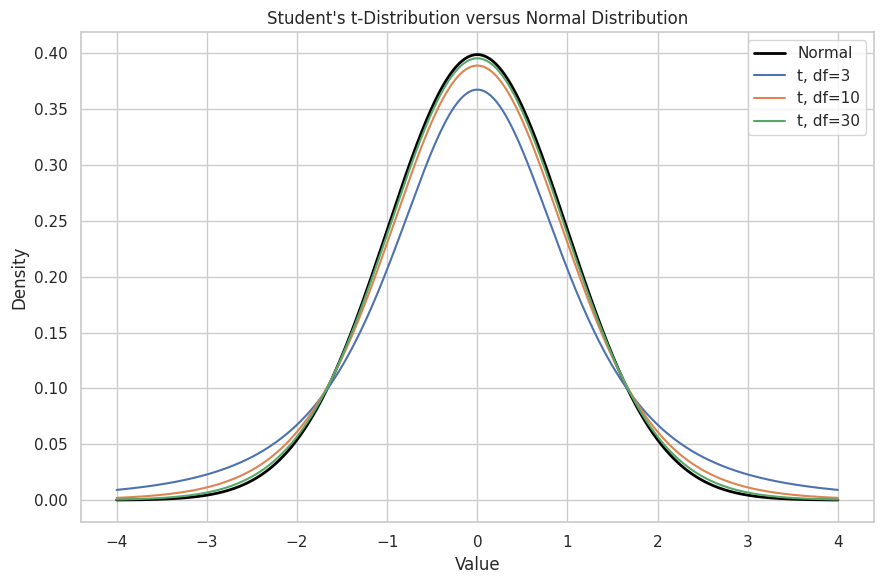

In [18]:
x_values = np.linspace(
    -4,
    4,
    500
)

plt.figure(figsize=(9, 6))

plt.plot(
    x_values,
    stats.norm.pdf(x_values),
    label="Normal",
    color="black",
    linewidth=2
)

for degrees_of_freedom in [
    3,
    10,
    30
]:
    plt.plot(
        x_values,
        stats.t.pdf(
            x_values,
            df=degrees_of_freedom
        ),
        label=(
            f"t, df="
            f"{degrees_of_freedom}"
        )
    )

plt.xlabel("Value")
plt.ylabel("Density")
plt.title(
    "Student's t-Distribution "
    "versus Normal Distribution"
)
plt.legend()
plt.tight_layout()
plt.show()

### Analisis t-Distribution

t-distribution dengan tiga degrees of freedom mempunyai ekor paling
tebal. Hal ini mencerminkan ketidakpastian yang lebih tinggi ketika
sample berukuran kecil.

Ketika degrees of freedom meningkat menjadi 30, bentuk t-distribution
hampir sama dengan normal distribution.

## 15. Binomial Distribution

Binomial distribution digunakan untuk menghitung jumlah keberhasilan
dari sejumlah eksperimen independen.

Syarat binomial distribution:

1. Jumlah percobaan $n$ tetap.
2. Setiap percobaan memiliki dua hasil, yaitu success atau failure.
3. Probabilitas success $p$ tetap.
4. Setiap percobaan independen.

Jika $X$ mengikuti binomial distribution:

$$
X \sim Binomial(n,p)
$$

Mean dan variance-nya adalah:

$$
E(X)=np
$$

$$
Var(X)=np(1-p)
$$

Bernoulli distribution merupakan kasus khusus binomial dengan satu
percobaan.

In [19]:
number_of_trials = 5
success_probability = 0.10

possible_successes = np.arange(
    number_of_trials + 1
)

binomial_probabilities = stats.binom.pmf(
    possible_successes,
    n=number_of_trials,
    p=success_probability
)

binomial_table = pd.DataFrame({
    "Number of Successes":
        possible_successes,
    "Probability":
        binomial_probabilities
})

display(binomial_table)

print(
    "Probability of exactly 2 successes:",
    round(
        stats.binom.pmf(
            2,
            n=number_of_trials,
            p=success_probability
        ),
        5
    )
)

print(
    "Probability of at most 2 successes:",
    round(
        stats.binom.cdf(
            2,
            n=number_of_trials,
            p=success_probability
        ),
        5
    )
)

,Number of Successes,Probability
0,0,0.5905
1,1,0.3280
2,2,0.0729
3,3,0.0081
4,4,0.0004
5,5,0.0000


Probability of exactly 2 successes: 0.0729
Probability of at most 2 successes: 0.99144


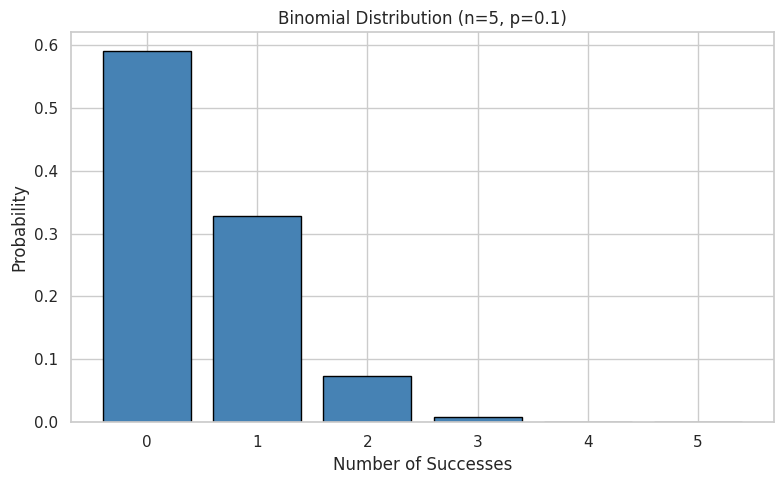

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    possible_successes,
    binomial_probabilities,
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.title(
    "Binomial Distribution "
    "(n=5, p=0.1)"
)
plt.xticks(possible_successes)
plt.tight_layout()
plt.show()

### Analisis Binomial Distribution

Peluang memperoleh tepat dua success dari lima percobaan dengan
probabilitas success 0,1 adalah sekitar 0,0729 atau 7,29%.

Peluang memperoleh paling banyak dua success adalah sekitar 0,99144
atau 99,144%. Cumulative distribution function menjumlahkan
probabilitas dari nol sampai dua success.

## 16. Chi-Square Distribution

Chi-square distribution merupakan distribusi dari penjumlahan kuadrat
sejumlah standard normal random variables.

Karakteristiknya:

- Hanya memiliki nilai non-negatif.
- Biasanya menceng ke kanan.
- Bentuknya ditentukan oleh degrees of freedom.
- Semakin besar degrees of freedom, bentuknya semakin simetris.

Distribusi ini digunakan untuk analisis varians, contingency table,
goodness-of-fit, dan berbagai statistical tests.

## 17. F-Distribution

F-distribution merupakan distribusi dari rasio dua variance yang telah
disesuaikan dengan degrees of freedom masing-masing.

Karakteristiknya:

- Hanya memiliki nilai non-negatif.
- Biasanya menceng ke kanan.
- Mempunyai numerator dan denominator degrees of freedom.

F-distribution digunakan dalam ANOVA, regression, dan perbandingan
variance. Pada bagian ini distribusinya hanya divisualisasikan;
pengujian statistik akan dibahas pada chapter berikutnya.

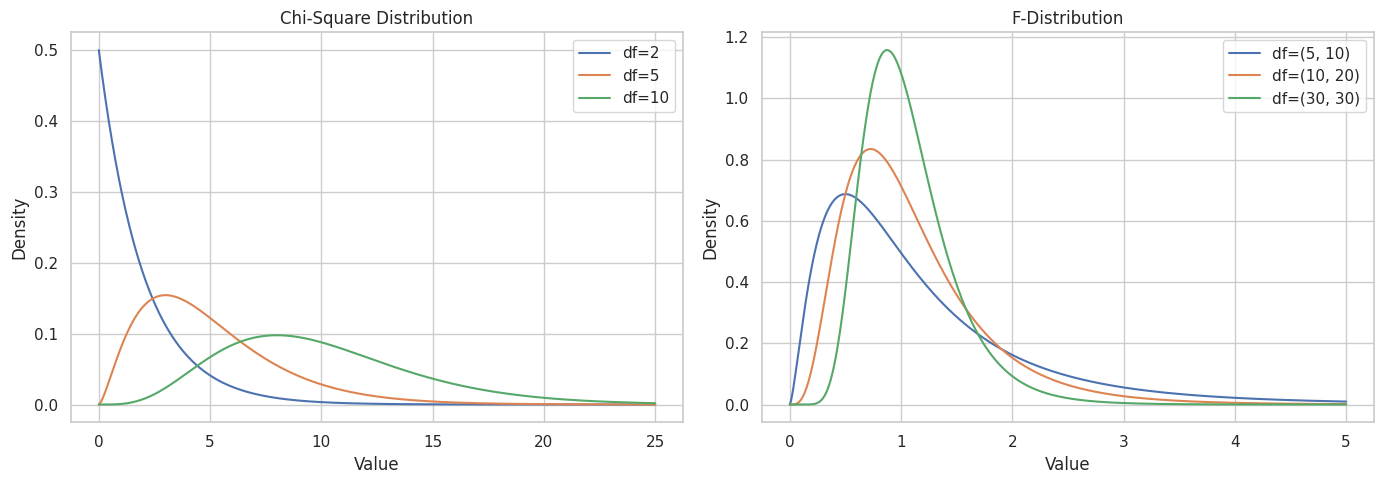

In [21]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

chi_square_x = np.linspace(
    0.001,
    25,
    500
)

for degrees_of_freedom in [
    2,
    5,
    10
]:
    axes[0].plot(
        chi_square_x,
        stats.chi2.pdf(
            chi_square_x,
            df=degrees_of_freedom
        ),
        label=(
            f"df="
            f"{degrees_of_freedom}"
        )
    )

axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].set_title(
    "Chi-Square Distribution"
)
axes[0].legend()

f_x = np.linspace(
    0.001,
    5,
    500
)

f_parameters = [
    (5, 10),
    (10, 20),
    (30, 30)
]

for numerator_df, denominator_df \
        in f_parameters:
    axes[1].plot(
        f_x,
        stats.f.pdf(
            f_x,
            dfn=numerator_df,
            dfd=denominator_df
        ),
        label=(
            f"df=({numerator_df}, "
            f"{denominator_df})"
        )
    )

axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].set_title(
    "F-Distribution"
)
axes[1].legend()

plt.tight_layout()
plt.show()

### Analisis Chi-Square dan F-Distribution

Chi-square distribution dengan degrees of freedom kecil terlihat sangat
menceng ke kanan. Ketika degrees of freedom meningkat, bentuknya menjadi
lebih simetris.

F-distribution juga hanya memiliki nilai positif dan menceng ke kanan.
Bentuknya berubah berdasarkan numerator dan denominator degrees of
freedom.

## 18. Poisson Distribution

Poisson distribution digunakan untuk memodelkan jumlah kejadian dalam
interval waktu atau ruang tertentu.

Contoh:

- Jumlah kendaraan yang datang setiap menit.
- Jumlah pesan yang diterima server setiap detik.
- Jumlah kerusakan komponen setiap bulan.

Jika rata-rata kejadian adalah $\lambda$, maka:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}
$$

Pada Poisson distribution:

$$
E(X)=\lambda
$$

$$
Var(X)=\lambda
$$

Asumsi sederhananya adalah kejadian independen dan rata-rata kejadian
relatif konstan.

## 19. Exponential Distribution

Exponential distribution digunakan untuk memodelkan waktu tunggu
antara dua kejadian Poisson.

Jika rate kejadian adalah $\lambda$, maka rata-rata waktu tunggu adalah:

$$
E(T)=\frac{1}{\lambda}
$$

Exponential distribution mempunyai sifat memoryless. Peluang menunggu
lebih lama tidak dipengaruhi oleh berapa lama waktu yang sudah berlalu.

## 20. Weibull Distribution

Weibull distribution banyak digunakan dalam reliability analysis untuk
memodelkan waktu hingga suatu komponen gagal.

Parameter utamanya adalah:

- **Shape parameter** $\beta$.
- **Scale parameter** $\eta$.

Interpretasi shape parameter:

- $\beta < 1$: failure rate menurun.
- $\beta = 1$: failure rate konstan dan sama dengan exponential.
- $\beta > 1$: failure rate meningkat akibat keausan.

In [22]:
poisson_generator = (
    np.random.default_rng(42)
)

exponential_generator = (
    np.random.default_rng(42)
)

weibull_generator = (
    np.random.default_rng(42)
)

poisson_sample = stats.poisson.rvs(
    mu=2,
    size=1000,
    random_state=poisson_generator
)

exponential_sample = stats.expon.rvs(
    scale=5,
    size=1000,
    random_state=exponential_generator
)

weibull_sample = stats.weibull_min.rvs(
    c=1.5,
    scale=5000,
    size=1000,
    random_state=weibull_generator
)

print(
    "Mean Poisson:",
    round(
        poisson_sample.mean(),
        3
    )
)

print(
    "Mean waiting time:",
    round(
        exponential_sample.mean(),
        3
    )
)

print(
    "Estimated exponential rate:",
    round(
        1 / exponential_sample.mean(),
        3
    )
)

print(
    "Mean Weibull lifetime:",
    round(
        weibull_sample.mean(),
        3
    )
)

Mean Poisson: 2.009
Mean waiting time: 5.072
Estimated exponential rate: 0.197
Mean Weibull lifetime: 4492.666


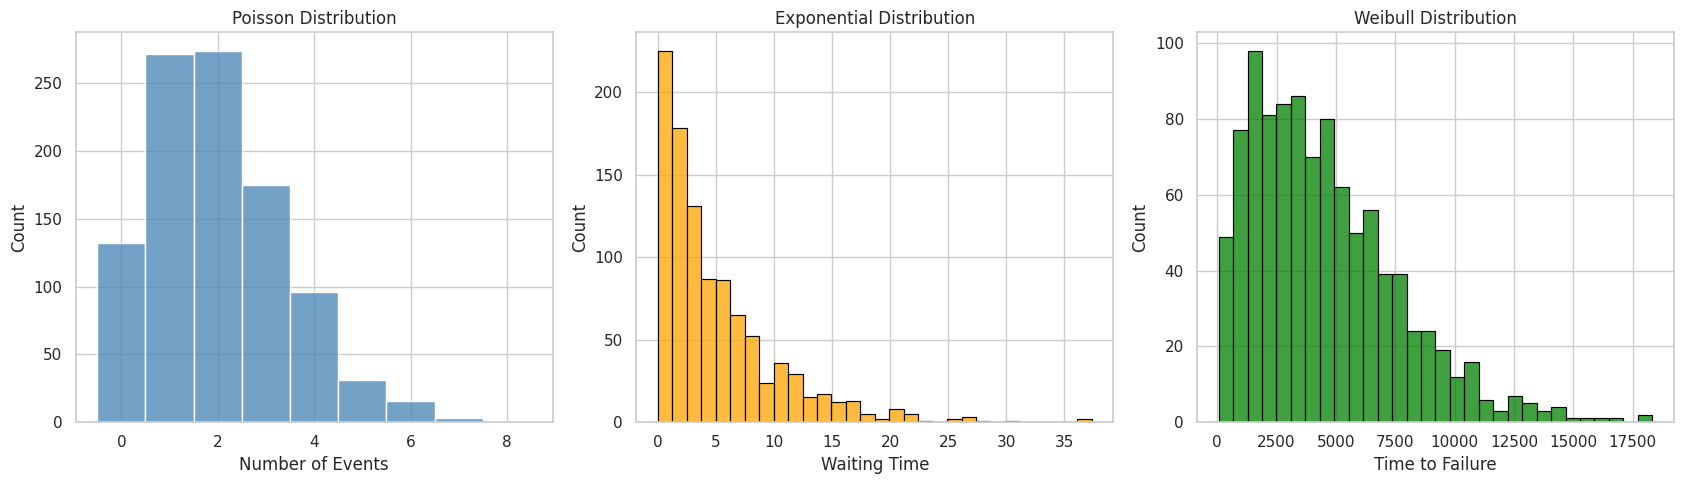

In [23]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

sns.histplot(
    poisson_sample,
    discrete=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_xlabel(
    "Number of Events"
)
axes[0].set_title(
    "Poisson Distribution"
)

sns.histplot(
    exponential_sample,
    bins=30,
    color="orange",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_xlabel(
    "Waiting Time"
)
axes[1].set_title(
    "Exponential Distribution"
)

sns.histplot(
    weibull_sample,
    bins=30,
    color="green",
    edgecolor="black",
    ax=axes[2]
)

axes[2].set_xlabel(
    "Time to Failure"
)
axes[2].set_title(
    "Weibull Distribution"
)

plt.tight_layout()
plt.show()

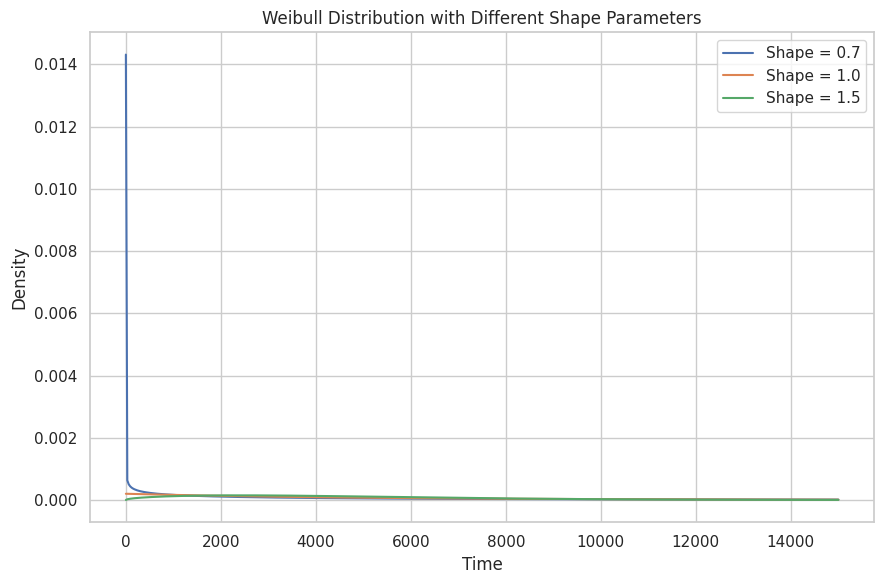

In [24]:
weibull_x = np.linspace(
    0.001,
    15_000,
    500
)

plt.figure(figsize=(9, 6))

for shape_parameter in [
    0.7,
    1.0,
    1.5
]:
    density = stats.weibull_min.pdf(
        weibull_x,
        c=shape_parameter,
        scale=5000
    )

    plt.plot(
        weibull_x,
        density,
        label=(
            f"Shape = "
            f"{shape_parameter}"
        )
    )

plt.xlabel("Time")
plt.ylabel("Density")
plt.title(
    "Weibull Distribution "
    "with Different Shape Parameters"
)
plt.legend()
plt.tight_layout()
plt.show()

### Analisis Poisson dan Related Distributions

Poisson sample menggunakan parameter lambda sebesar 2. Sample mean
sekitar 2,009, mendekati nilai lambda yang ditentukan.

Exponential sample menggunakan scale sebesar 5. Karena scale adalah
kebalikan dari rate, rate teoretisnya adalah 0,2. Hasil estimasi sample
sekitar 0,197, sehingga mendekati nilai teoretis.

Weibull sample menggunakan shape 1,5 dan scale 5.000. Shape yang lebih
besar dari satu dapat digunakan untuk merepresentasikan failure rate
yang meningkat seiring waktu, seperti kerusakan akibat keausan.

## 23. References

1. Bruce, P., Bruce, A., & Gedeck, P. (2020).
   *Practical Statistics for Data Scientists: 50+ Essential Concepts
   Using R and Python* (2nd ed.). O'Reilly Media.

2. Official Book Repository — Chapter 2.  
   https://github.com/gedeck/practical-statistics-for-data-scientists

3. SciPy Statistical Functions.  
   https://docs.scipy.org/doc/scipy/reference/stats.html

4. NumPy Documentation.  
   https://numpy.org/doc/

5. Pandas Documentation.  
   https://pandas.pydata.org/docs/

6. Matplotlib Documentation.  
   https://matplotlib.org/stable/

7. Seaborn Documentation.  
   https://seaborn.pydata.org/